# Lab 3: Pandas

(Last update: 01/12/2024)

Full name: Nguyễn Phúc Khang
Student ID: 22127180

---

**Summary**: In this assignment, you are going to learn how to use `Pandas`. Loops, and methods such as `apply/applymap` are not allowed to use unless specifically instructed to do so.

## 0. General instructions

### 0.0. Work on assignment

- You will do your assignment directly on this notebook file. First, you fill your name and student code at the beginning of the file. In this file, you will write your code when you see the following lines of code:
    ```python
    # TODO
    raise NotImplementedError()
    ```

    For optional coding parts, there will be:

    ```python
    # TODO (OPTIONAL)
    ```

    For markdown cell, there will be:

    ```markdown
    **TODO**: ...
    ```

- Of course, you have to remove the `raise NotImplementedError()` statement when you finish.

- For coding parts, there are often cells below to help you check your answers. You will pass the test if there are no errors when you run the test cells. In some cases, the tests are insufficient. That means if you do not pass the test, your answer is definitely wrong somewhere, but if you pass the test, your answer may still be incorrect.

- While doing the assignment, you should print out the output and create more cells for testing. But you have to remove all of them (comment your print-out codes, delete the cell created by you) when you submit your code. <font color=red>Do not remove or edit my cells</font> (except for the aforementioned cells).

- Keep your code clean and clear by using meaningful variable names and comments, not write too-long coding lines. Press `Ctrl + S` right after editing.

- **Keep it real**: The reason why you are here is to <font color=green>study, really study</font>. I highly recommend that you discuss your idea with your friends and <font color=green>write your own code based on your own knowledge</font>. <font color=red>Copy means zero.</font>

### 0.1. Submit your assignment

- When grading your assignment, I will choose `Kernel` - `Restart & Run All` in order to restart the kernel and run all cells in your notebook. Therefore, you should do that before submitting to ensure that the outputs are all as expected.

- After that, rename the notebook as `<StudentID>.ipynb`. For example, if your student code is 1234567, then your notebook is `1234567.ipynb`.

- Finally, submit your notebook file on Moodle. <font color=red>Please strictly follow the submission rules.</font>

---

## 1. Import libraries

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.simplefilter('ignore')

# TODO (OPTION): import your libraries

## 2. Data collection

- In this assignment, you are going to analyze **Most Streamed Spotify Songs 2024**. You are provided the following files:
    - `./Most Streamed Spotify Songs 2024.csv`.

- Data source: [Most Streamed Spotify Songs 2024 - Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024).

## 3. Data pre-processing and exploration

- In this section, you are going to explore features of data. First, you have to read the data from `./Most Streamed Spotify Songs 2024.csv` and store it into a dataframe called `df`.

In [2]:
# TODO: read data from ./Most Streamed Spotify Songs 2024.csv and save to df then display 5 first lines of data
# raise NotImplementedError()
df = pd.read_csv('./Most Streamed Spotify Songs 2024.csv')
df.head(5)

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


### 3.0. How many rows/columns are there in the dataset?

- Save the number of rows and columns to `n_rows, n_cols`

In [3]:
# TODO: save your answer to n_rows, n_cols
# raise NotImplementedError()
n_rows, n_cols = df.shape

In [4]:
# TEST
assert (n_rows, n_cols) == (4600, 29)

### 3.1. Explore rows

- Is there any duplicate row? You will check it using `Pandas`.

In [5]:
# TODO: save your answer to is_duplicate
# raise NotImplementedError()
is_duplicate = df.duplicated().any()

In [6]:
# TEST
assert is_duplicate == True

So there are duplicate rows. Delete them and keep only one using Pandas.

In [7]:
# TODO: Remove duplicate rows and keep only one
# raise NotImplementedError()
df = df.drop_duplicates()

In [8]:
# TEST
assert df.shape == (4598, 29)

### 3.2. Explore columns

- Observe the data provided, carefully read the column titles as well as the data contained in the columns.
- Display the column names.

In [9]:
# TODO: Display the column names
# raise NotImplementedError()
df.columns

Index(['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts',
       'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach',
       'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins',
       'Deezer Playlist Count', 'Deezer Playlist Reach',
       'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations',
       'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity',
       'Explicit Track'],
      dtype='object')

### 3.3. Handle missing data & Convert data

- Next, we start handling missing data. First thing first, please display the data information.

In [10]:
# TODO: Display data information
# raise NotImplementedError()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4598 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4598 non-null   object 
 1   Album Name                  4598 non-null   object 
 2   Artist                      4593 non-null   object 
 3   Release Date                4598 non-null   object 
 4   ISRC                        4598 non-null   object 
 5   All Time Rank               4598 non-null   object 
 6   Track Score                 4598 non-null   float64
 7   Spotify Streams             4485 non-null   object 
 8   Spotify Playlist Count      4528 non-null   object 
 9   Spotify Playlist Reach      4526 non-null   object 
 10  Spotify Popularity          3794 non-null   float64
 11  YouTube Views               4290 non-null   object 
 12  YouTube Likes               4283 non-null   object 
 13  TikTok Posts                3425 non-n

- Display number of NA values in each column.

In [11]:
# TODO: Display number of NA values in each column.
# raise NotImplementedError()
df.isna().sum()

Track                            0
Album Name                       0
Artist                           5
Release Date                     0
ISRC                             0
All Time Rank                    0
Track Score                      0
Spotify Streams                113
Spotify Playlist Count          70
Spotify Playlist Reach          72
Spotify Popularity             804
YouTube Views                  308
YouTube Likes                  315
TikTok Posts                  1173
TikTok Likes                   980
TikTok Views                   981
YouTube Playlist Reach        1009
Apple Music Playlist Count     561
AirPlay Spins                  498
SiriusXM Spins                2123
Deezer Playlist Count          921
Deezer Playlist Reach          928
Amazon Playlist Count         1055
Pandora Streams               1106
Pandora Track Stations        1268
Soundcloud Streams            3332
Shazam Counts                  577
TIDAL Popularity              4598
Explicit Track      

- As you can see, the TIDAL Popularity column contains only NA values, so let's remove it.

In [12]:
# TODO: Remove TIDAL Popularity column out of the df
# raise NotImplementedError()
df = df.drop(columns=['TIDAL Popularity'])
df[['Amazon Playlist Count']].sum()

Amazon Playlist Count    89801.0
dtype: float64

In [13]:
# TEST
assert 'TIDAL Popularity' not in df.columns

### 3.4. Data distribution

#### 3.4.1. Histogram:

Visualize the histogram of Spotify Streams.

You should follow these steps:
- Step 1: Fill NaN in Spotify Streams with 0.
- Step 2: Convert it to numeric
- Step 3: Display the histogram

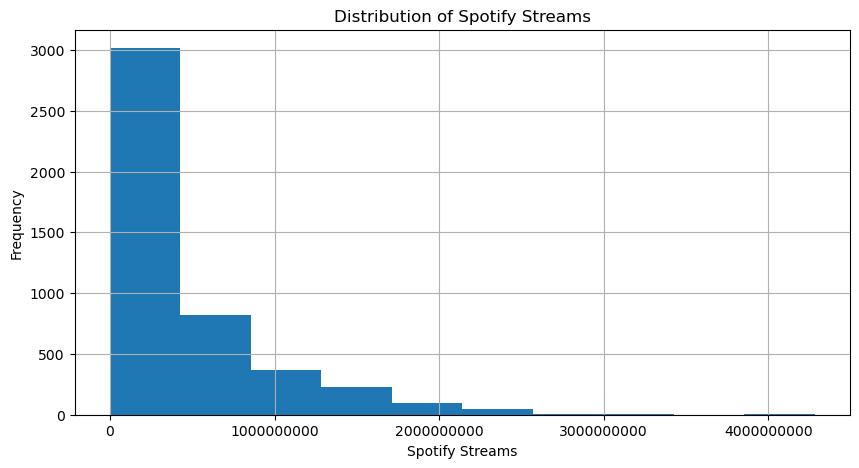

In [14]:
# TODO: Visualize the distribution of Spotify Streams
# raise NotImplementedError()

# Step 1: Fill NaN in Spotify Streams with 0
df['Spotify Streams'] = df['Spotify Streams'].fillna(0)

# Step 2: Convert it to numeric
df['Spotify Streams'] = df['Spotify Streams'].replace({',': ''}, regex=True) 
df['Spotify Streams'] = pd.to_numeric(df['Spotify Streams'], errors='coerce')

# Step 3: Display the histogram
plt.figure(figsize=(10, 5))
plt.hist(df['Spotify Streams'], bins=10)  
plt.ticklabel_format(style='plain', axis='x')
plt.title('Distribution of Spotify Streams')
plt.xlabel('Spotify Streams')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

- What is your insights about above histogram?

    **TODO**: 
    
    **Highly Skewed Distribution**:
    - Most tracks have relatively low stream counts, with a significant peak concentrated near the lower end of the distribution (fewer than 100,000,000 streams).
    - Over 3,000 tracks fall within the first bin, indicating that the majority of songs have much lower visibility or popularity compared to the top-streamed tracks.
    - A small number of tracks have exceptionally high stream counts, standing out as outliers in the dataset.

    **Exponential Decay Trend**:
    - As the stream count increases, the frequency of tracks decreases rapidly, highlighting a Pareto-like distribution where a small fraction of tracks accounts for a large portion of the total streams.

    **Practical Implications**: 
    - The dominance of a limited number of tracks in terms of stream count indicates the music industry's "hit-driven" character. Several popular songs or artists often dominate audience attention and income. 
    - Breaking into the top-streamed category is extremely competitive for budding artists, with the majority of tracks remaining in the low exposure level.
    - The data shows that audiences tend to focus their listening habits on a small number of very popular tracks, indicating that platforms should vary their recommendation algorithms to expose consumers to lesser-known music.
    - Since revenue from streaming is proportional to the number of streams, the majority of artists likely earn significantly less compared to the few top-performing artists. This reinforces the financial inequality in the music industry and the need for more equitable revenue-sharing models.



#### 3.4.2. Boxplot:

Visualize the Boxplot of Track Score.

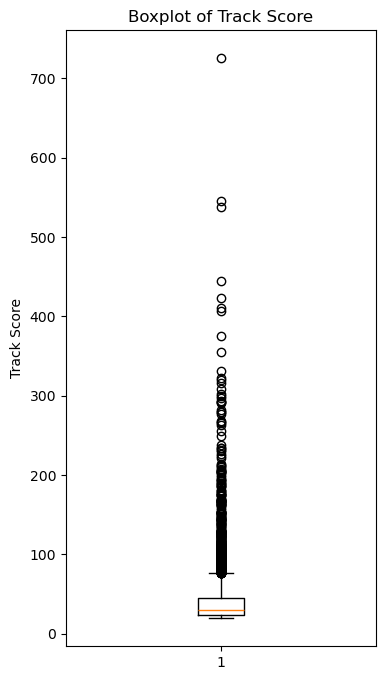

In [15]:
# TODO: Visualize the boxplot of Track Score
# raise NotImplementedError()
plt.figure(figsize=(4, 8))
plt.boxplot(df['Track Score'])
plt.title('Boxplot of Track Score')
plt.ylabel('Track Score')
plt.show()

- What is your insights about above box plot?

    **TODO**: 

    **Key Observations from the Boxplot**:
    - There are several outliers with scores significantly higher than the main body of the data, with some exceeding 700. These outliers represent a small group of tracks that have achieved exceptionally high performance compared to the majority.

    - The median (orange line) is positioned closer to the lower quartile, indicating that the data is right-skewed. This suggests most tracks have relatively low scores, while a few have substantially higher scores.

    - The height of the box (IQR) is relatively small, showing that the majority of tracks have scores within a narrow range. This indicates a consistent performance among most tracks.

    - The upper whisker extends beyond the IQR, representing tracks with moderately higher scores that are not extreme enough to be considered outliers. 

    **Practical Implications**:
   - The presence of outliers suggests a small subset of tracks achieves exceptional success. For record labels or artists, focusing resources on promoting these high-performing tracks can maximize impact and revenue.
   - Playlists and features can be used to further amplify the reach of tracks with high potential.
   - Since most tracks cluster in a narrow range with lower scores, platforms can consider initiatives to provide visibility to these tracks. For example, curated playlists, personalized recommendations, and promotional campaigns could help bridge the gap for lesser-known artists.



#### 3.4.3. Pie chart:

Visualize the pie chart showing the distribution of Explicit Track.

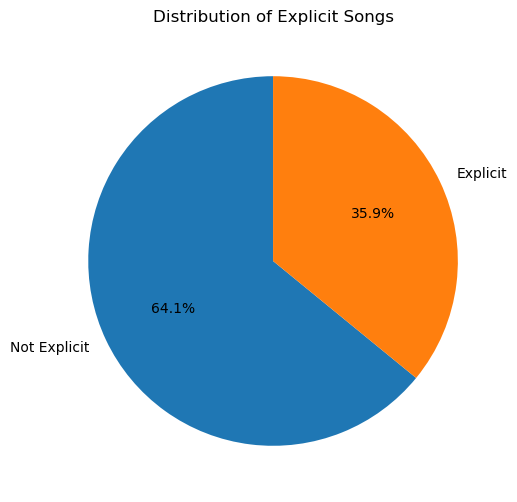

In [16]:
# TODO: Visualize the pie chart showing the distribution of Explicit Track
# raise NotImplementedError()
plt.figure(figsize=(6, 6))
plt.pie(df['Explicit Track'].value_counts(), 
        labels=['Not Explicit', 'Explicit'], 
        autopct='%1.1f%%',
        startangle=90)
plt.title('Distribution of Explicit Songs')
plt.show()

- What is your insights about above pie chart?

    **TODO**: 

    **The majority of tracks are not explicit**:
    - 64.1% of the tracks are labeled as "Not Explicit," indicating that most tracks in the dataset do not contain explicit content.
    - 35.9% of the tracks are tagged as "Explicit." Although this is less than half, it represents a relatively high proportion, showing that explicit songs are fairly common and not significantly lower in prevalence compared to non-explicit tracks.

    **Practical Implications**:
    - The relatively high proportion of explicit tracks highlights the growing acceptance and demand for explicit content in the music industry, particularly among audiences who prefer raw or unfiltered lyrics.
    - This distribution suggests that platforms and artists need to cater to diverse listener preferences, ensuring proper content labeling for explicit tracks to maintain inclusivity for different age groups and sensitivities.


## 4. Question proposing & Answering

- In this section, you are going to answer my 2 questions and prose 1 question. Note that these questions can all be answered by analyzing data. Theoretically, the proposed question have to benefit at a certain level. But this is exercise about `Pandas`, my questions can be aimed more at technical side than the meaningful side. But your question has to be meaningful :v

### 4.1. Top 10 songs by streams

Find and display the top 10 songs with the highest number of streams in 2024.

In [17]:
# TODO: Answer the question
# raise NotImplementedError()
top_10_songs = df.sort_values(by='Spotify Streams', ascending=False).reset_index(drop=True)
top_10_songs = top_10_songs[['Track', 'Artist', 'Spotify Streams']]
top_10_songs = top_10_songs.head(10)
top_10_songs

,Track,Artist,Spotify Streams
0,Blinding Lights,The Weeknd,4281468720
1,Blinding Lights,xSyborg,4261328190
2,Shape of You,Ed Sheeran,3909458734
3,Shape of You,xSyborg,3888356417
4,Someone You Loved,Lewis Capaldi,3427498835
5,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,3358704125
6,As It Was,Harry Styles,3301814535
7,As It Was,Harry Styles,3299082422
8,Starboy,The Weeknd,3291262413
9,One Dance,Drake,3192204066


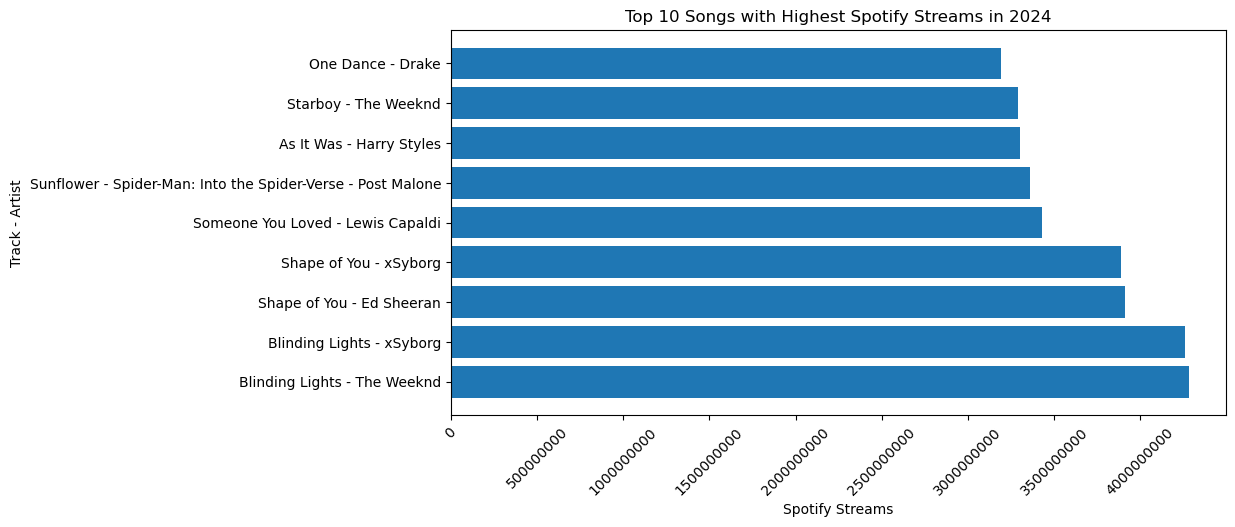

In [18]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(10, 5))
plt.barh(top_10_songs['Track'] + ' - ' + top_10_songs['Artist'], top_10_songs['Spotify Streams'])
plt.xlabel('Spotify Streams')
plt.ylabel('Track - Artist')
plt.title('Top 10 Songs with Highest Spotify Streams in 2024')
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)
plt.show()

### 4.2. Top 10 Artists by streams

Find and display the top 10 artists with the highest number of streams in 2024.

In [19]:
# TODO: Answer the question
# raise NotImplementedError()
top_10_artists = df[['Artist', 'Spotify Streams']].groupby('Artist').sum().sort_values(by='Spotify Streams', ascending=False)
top_10_artists = top_10_artists.head(10)
top_10_artists

,Spotify Streams
Artist,
Bad Bunny,37054834425
The Weeknd,36948540278
Drake,34962157577
Taylor Swift,34470771165
Post Malone,26137472958
Ed Sheeran,24014900390
Ariana Grande,23464991696
MUSIC LAB JPN,22866685573
Olivia Rodrigo,19729219749


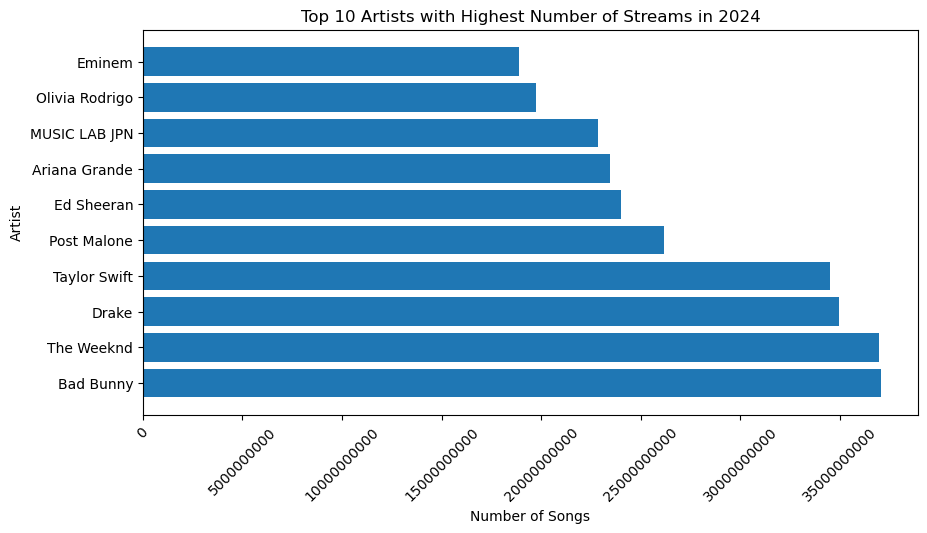

In [20]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(10, 5))
plt.barh(top_10_artists.index, top_10_artists['Spotify Streams'])
plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.title('Top 10 Artists with Highest Number of Streams in 2024')
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)
plt.show()

### 4.3. Which platforms contribute most to overall Streams?

In [21]:
# TODO: Answer the question
# raise NotImplementedError()
platforms = ['Spotify Streams',
             'Pandora Streams', 
             'Soundcloud Streams']

platforms_data = df[platforms].fillna(0).replace({',': ''}, regex=True).astype(np.uint64)
platform_totals = platforms_data.sum().sort_values(ascending=False)
platform_totals

Spotify Streams       2006619798153
Pandora Streams        299258021879
Soundcloud Streams      18811039941
dtype: uint64

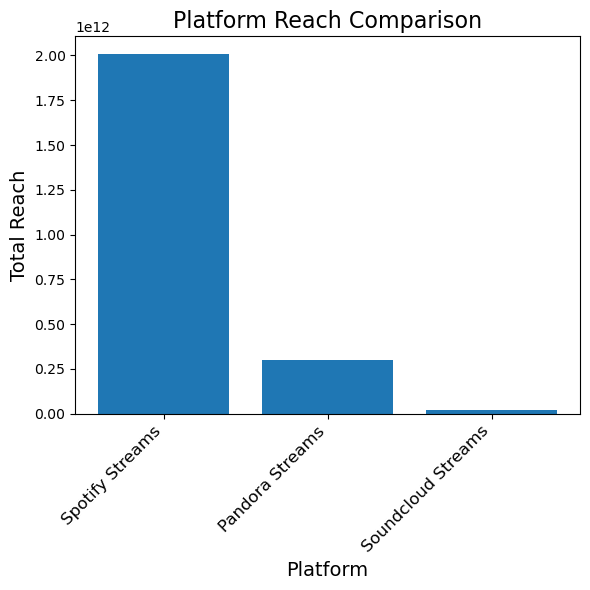

In [22]:
# TODO (OPTIONAL): Visualize
# Visualization
plt.figure(figsize=(6, 6))
plt.bar(platform_totals.index, platform_totals.values)
plt.title("Platform Reach Comparison", fontsize=16)
plt.xlabel("Platform", fontsize=14)
plt.ylabel("Total Reach", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()


**TODO**

**Dominance of Spotify**:
   - Spotify contributes overwhelmingly to total streams, accounting for the majority share. This reflects its dominance as the leading global music streaming platform.
   - Spotify's extensive user base, playlist system, and high engagement levels make it the primary driver of streaming activity.

**Pandora's Significant Share**:
   - Despite being limited to certain regions, Pandora holds the second-largest share of streams. This indicates its strong user loyalty and niche audience, particularly in the United States.


**Lower Contribution from SoundCloud**:
   - SoundCloud contributes significantly fewer streams compared to Spotify and Pandora. This may be due to its focus on independent and emerging artists, leading to smaller audiences.
   - However, it remains an essential platform for discovering niche or underground music that might not be available on mainstream platforms.

Well done!